Total Mass:0.10286141265785262 Mg
Total Mass:102.86141265785263 kg
Projected Surface Area: 352919.4186408549 mm^2


Text(0.5, 0, 's')

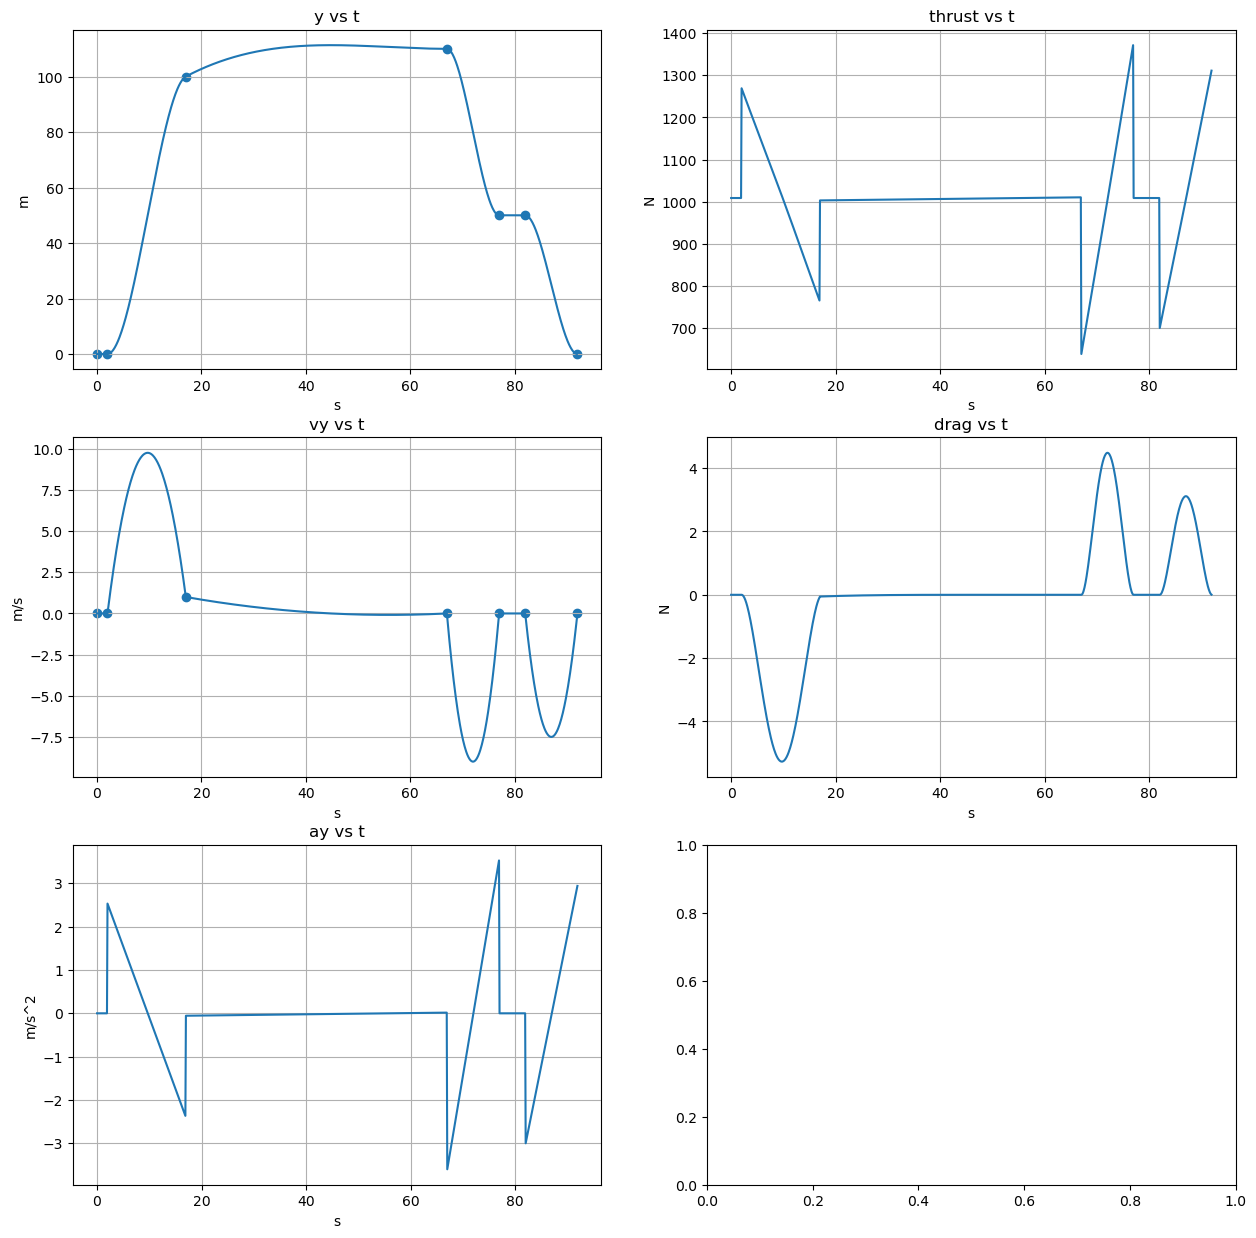

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from Scripts.mission_profile import MissionProfile
from Scripts.drone_forces import DroneForces
from Scripts.drone_battery import Battery
from Scripts.beams import BeamType
from Scripts.drone_geometry import DroneGeometry
from Scripts.drone_mass import DroneMass

drag_coeff = 0.256

m1 = MissionProfile("m1", 0, 0, 1)

battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))
arm_beam = BeamType("annulus", [29, 25], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [14, 12], "Aluminum7075-T6", "strut_beam")
d1_geo = DroneGeometry("drone_test", 1000, 660, 8, arm_beam, strut_beam, [battery_1, battery_2])
d1_mass = DroneMass(d1_geo)


total_mass = d1_mass.total_mass + 90 * 10 ** -3
surface_area = d1_geo.projected_surface_area
print("Total Mass:" + str(total_mass) + " Mg")
print("Total Mass:" + str(total_mass*1000) + " kg")
print("Projected Surface Area: " + str(surface_area) + " mm^2")

m1.add_segment("takeoff",2,0,2,0,1)
m1.add_segment("climb",15,550000,100000,300,1000)
m1.add_segment("cruise",50,2000000,110000,300,0)
m1.add_segment("descent",10,2200000,50000,0,0)
m1.add_segment("loiter",5,2200000,50000,0,0)
m1.add_segment("land",10,1200000,0,0,0)

d1_forces = DroneForces(total_mass, surface_area, drag_coeff, m1)

list_t = np.arange(0, m1.t_values[-1], 0.1)

y = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))
thrust_y = np.zeros(len(list_t))
drag_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    x_result, y_result, name = m1.time_solve(t)
    t_y, d_y = d1_forces.time_solve(t)
    y[i] = y_result[0]
    v_y[i] = y_result[1]
    a_y[i] = y_result[2]
    thrust_y[i] = t_y
    drag_y[i] = d_y

fig, axs = plt.subplots(3, 2)

fig.set_figheight(15)
fig.set_figwidth(15)


axs[0,0].set_title("y vs t")
axs[0,0].plot(list_t, y/1000)
axs[0,0].scatter(m1.t_values,m1.y_coords/1000)
axs[0,0].grid()
axs[0,0].set_ylabel("m")
axs[0,0].set_xlabel("s")


axs[1,0].set_title("vy vs t")
axs[1,0].plot(list_t, v_y/1000)
axs[1,0].scatter(m1.t_values,m1.vel_y_values/1000)
axs[1,0].grid()
axs[1,0].set_ylabel("m/s")
axs[1,0].set_xlabel("s")


axs[2,0].set_title("ay vs t")
axs[2,0].plot(list_t,a_y/1000)
axs[2,0].grid()
axs[2,0].set_ylabel("m/s^2")
axs[2,0].set_xlabel("s")

axs[0,1].set_title("thrust vs t")
axs[0,1].plot(list_t, thrust_y)
axs[0,1].grid()
axs[0,1].set_ylabel("N")
axs[0,1].set_xlabel("s")

axs[1,1].set_title("drag vs t")
axs[1,1].plot(list_t, drag_y)
axs[1,1].grid()
axs[1,1].set_ylabel("N")
axs[1,1].set_xlabel("s")


#draw.io